# TABELAS E CÓDIGOS DO EXPERIMENTO DA CARGA/MASSA DO ELÉTRON

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Experimento sem campo elétrico:

In [3]:
sigV1 = 0.3 # Volts
sigA = 0.01 # Amperes
sigM = 1 # Milímetros
sigV2 = 10 # Volts
Voltagem1 = np.array([1.2,  1.8,  3,    3,    4.2,  4.8,  5.4,  5.4,  6,    6.6])
Amperagem = np.array([0.12, 0.15, 0.21, 0.26, 0.32, 0.36, 0.40, 0.42, 0.45, 0.51])
Quadrados = np.array([7,    9,    14,   16,   20,   22,   24,   25,   27,   30])
Quadrados = Quadrados * 2 # Convertendo para milímetros

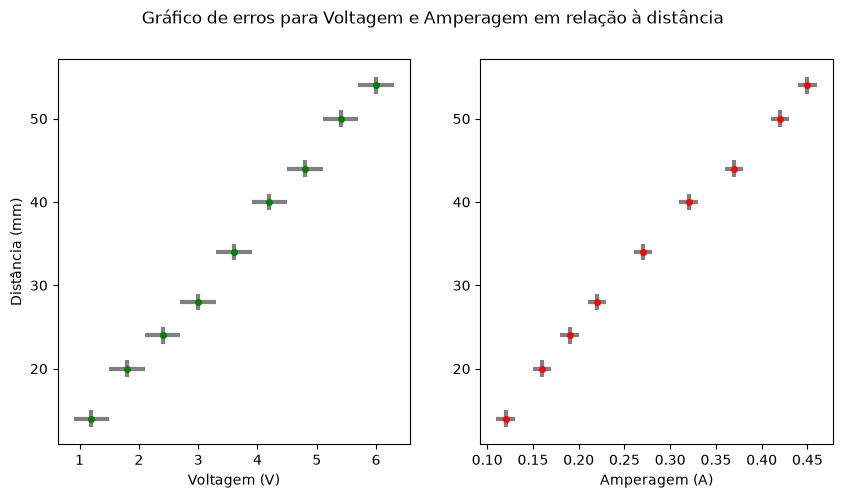

In [35]:
fig, ax1 = plt.subplots(1,2, figsize=(10, 5))

ax1[0].errorbar(Voltagem1, Quadrados, xerr=sigV1, yerr=sigM, fmt='o', markersize=4, color='green', ecolor='gray', elinewidth=3, capsize=0)
ax1[0].set_xlabel('Voltagem (V)')
ax1[0].set_ylabel('Distância (mm)')

ax1[1].errorbar(Amperagem, Quadrados, xerr=sigA, yerr=sigM, fmt='o', markersize=4, color='red', ecolor='gray', elinewidth=3, capsize=0)
ax1[1].set_xlabel('Amperagem (A)')
fig.suptitle('Gráfico de erros para Voltagem e Amperagem em relação à distância')
plt.show()


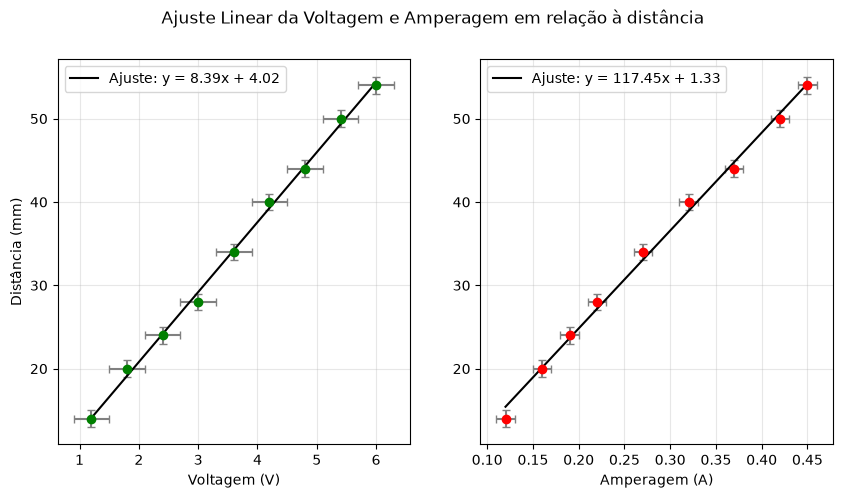

Voltagem: y = 8.3889x + 4.0222
Amperagem: y = 117.4545x + 1.3349


In [36]:
# Ajuste linear por minimos quadrados: y = a*x + b
coef_v = np.polyfit(Voltagem1, Quadrados, 1)
coef_i = np.polyfit(Amperagem, Quadrados, 1)

reta_v = np.polyval(coef_v, Voltagem1)
reta_i = np.polyval(coef_i, Amperagem)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].errorbar(Voltagem1, Quadrados, xerr=sigV1, yerr=sigM, fmt='o', color='green', ecolor='gray', capsize=3)
ax[0].plot(Voltagem1, reta_v, color='black', label=f'Ajuste: y = {coef_v[0]:.2f}x + {coef_v[1]:.2f}')
ax[0].set_xlabel('Voltagem (V)')
ax[0].set_ylabel('Distância (mm)')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].errorbar(Amperagem, Quadrados, xerr=sigA, yerr=sigM, fmt='o', color='red', ecolor='gray', capsize=3)
ax[1].plot(Amperagem, reta_i, color='black', label=f'Ajuste: y = {coef_i[0]:.2f}x + {coef_i[1]:.2f}')
ax[1].set_xlabel('Amperagem (A)')
ax[1].grid(alpha=0.3)
ax[1].legend()

fig.suptitle('Ajuste Linear da Voltagem e Amperagem em relação à distância')
plt.show()

print(f'Voltagem: y = {coef_v[0]:.4f}x + {coef_v[1]:.4f}')
print(f'Amperagem: y = {coef_i[0]:.4f}x + {coef_i[1]:.4f}')

Experimento com campo elétrico

In [6]:
Voltagem1 = np.array([1.2,  1.8,  2.4,  3,    3.6,  4.2,  4.8,  5.4,  6])
Amperagem = np.array([0.12, 0.16, 0.19, 0.22, 0.27, 0.32, 0.37, 0.42, 0.45])
Quadrados = np.array([7,    10,   12,   14,   17,   20,   22,   25,   27])
Quadrados = Quadrados * 2 # Convertendo para milímetros
Voltagem2 = np.array([120,  180,  220,  260,   300, 360,  400,  460,  500])

In [18]:
Raios = np.array([5,4,3,2])
Corrente_150 = [0.96, 1.34, 1.82, 3.12]
Tensao_150 = [4,6,8,15]
Corrente_200 = [1.23, 1.54, 2.12, 3.48]
Tensao_200 = [5,7,10,17]
Corrente_250 = [1.36, 1.74, 2.33, 3.75]
Tensao_250 = [6,8,11,18]
Corrente_300_15 = [1.43, 1.79, 2.42, 3.91]
Tensao_300_15 = [6,8,12,19]
Corrente_300_50 = [1.54, 1.95, 2.64, 3.84]
Tensao_300_50 = [6,9,13,19]
table = np.array([Corrente_150, Tensao_150, Corrente_200, Tensao_200, Corrente_250, Tensao_250, Corrente_300_15, Tensao_300_15, Corrente_300_50, Tensao_300_50])
print(table)
print(Raios)

[[ 0.96  1.34  1.82  3.12]
 [ 4.    6.    8.   15.  ]
 [ 1.23  1.54  2.12  3.48]
 [ 5.    7.   10.   17.  ]
 [ 1.36  1.74  2.33  3.75]
 [ 6.    8.   11.   18.  ]
 [ 1.43  1.79  2.42  3.91]
 [ 6.    8.   12.   19.  ]
 [ 1.54  1.95  2.64  3.84]
 [ 6.    9.   13.   19.  ]]
[5 4 3 2]


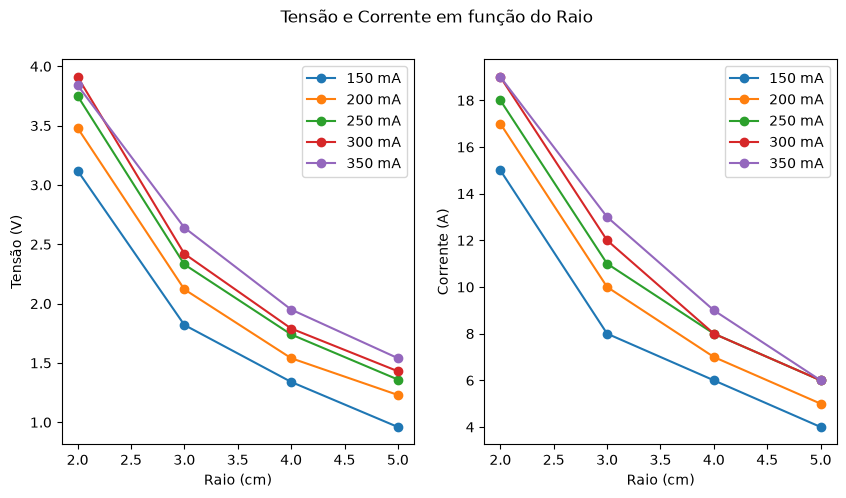

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for i,line in enumerate(table):
    if i % 2 == 0:
        ax[0].plot(Raios,line, marker='o', label=f'{150 + (i//2)*50} mA')
    else:
        ax[1].plot(Raios,line, marker='o', label=f'{150 + ((i-1)//2)*50} mA')
ax[0].set_xlabel('Raio (cm)')
ax[0].set_ylabel('Tensão (V)')
ax[0].legend()
ax[1].set_xlabel('Raio (cm)')
ax[1].set_ylabel('Corrente (A)')
ax[1].legend()
fig.suptitle('Tensão e Corrente em função do Raio')
plt.show()
